# Experiment visualization

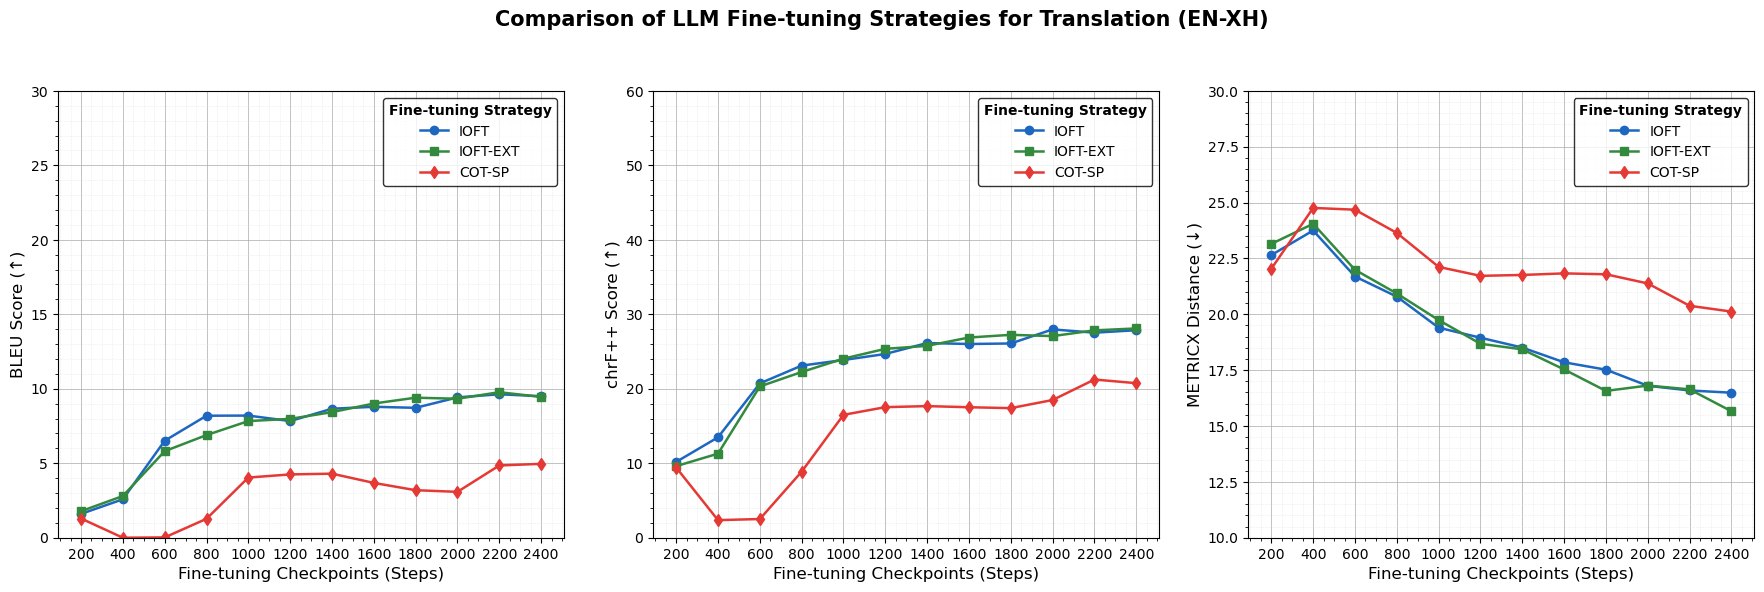

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker



def _to_float(series):
    # Convert decimal-comma strings like "1,60" to floats.
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False).str.strip(),
        errors="coerce",
    )

def _map_strategy_label(strategy_name):
    s = str(strategy_name).strip()
    s_upper = s.upper()
    if "EXT" in s_upper:
        return "IOFT-EXT"
    if "COT" in s_upper and "SP" in s_upper:
        return "COT-SP"
    if "IOFT" in s_upper:
        return "IOFT"
    return s

def load_wide_metrics_csv(csv_path):
    """
    Parse the wide CSV export where:
    - row 0 contains strategy block names
    - row 1 contains metric names (checkpoint, BLEU, chrF++, metricx)
    - rows 2+ contain values
    """
    raw = pd.read_csv(csv_path, header=None)

    if raw.shape[0] < 3:
        raise ValueError("CSV does not contain enough rows to parse.")

    row0 = raw.iloc[0].fillna("").astype(str)
    row1 = raw.iloc[1].fillna("").astype(str)
    data = raw.iloc[2:].copy().reset_index(drop=True)

    # First column is checkpoint in this file format.
    checkpoints = pd.to_numeric(data.iloc[:, 0], errors="coerce")

    blocks = []

    for idx in range(1, len(row1) - 2):
        metric_name = row1.iloc[idx].strip().lower()
        if metric_name != "bleu":
            continue
        strategy_name = row0.iloc[idx].strip()
        if not strategy_name:
            continue

        block = pd.DataFrame(
            {
                "Checkpoint_cleaned": checkpoints,
                "Strategy": strategy_name,
                "BLEU": _to_float(data.iloc[:, idx]),
                "chrF++": _to_float(data.iloc[:, idx + 1]),
                "metricx": _to_float(data.iloc[:, idx + 2]),
            }
        )
        block["Strategy_Label"] = block["Strategy"].map(_map_strategy_label)
        blocks.append(block)

    if not blocks:
        raise ValueError("No metric blocks were found in the CSV header.")

    df = pd.concat(blocks, ignore_index=True)
    df = df.dropna(subset=["Checkpoint_cleaned", "BLEU", "chrF++", "metricx"])
    df["Checkpoint_cleaned"] = df["Checkpoint_cleaned"].astype(int)

    # Some exports duplicate the same strategy block; collapse duplicates safely.
    df = (
        df.groupby(["Checkpoint_cleaned", "Strategy_Label"], as_index=False)[
            ["BLEU", "chrF++", "metricx"]
        ].mean().sort_values(["Strategy_Label", "Checkpoint_cleaned"])
    )
    return df

def compare_metrics(csv_path):
    """
    Load experiment data and generate comparative plots for IOFT, IOFT-EXT, and COT-SP.
    """
    try:
        df_filtered = load_wide_metrics_csv(csv_path)

        styles = {
            "IOFT": {"color": "#1E67C1", "marker": "o", "linestyle": "-", "linewidth": 1.8},
            "IOFT-EXT": {"color": "#338A3E", "marker": "s", "linestyle": "-", "linewidth": 1.8},
            "COT-SP": {"color": "#E53935", "marker": "d", "linestyle": "-", "linewidth": 1.8},
        }

        plt.rcParams["font.family"] = "sans-serif"
        fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True)
        fig.suptitle(
            "Comparison of LLM Fine-tuning Strategies for Translation (EN-XH)",
            fontsize=15,
            fontweight="bold",
            y=1.0,
        )

        metrics = ["BLEU", "chrF++", "metricx"]
        axis_config = {
            "BLEU": {"label": "BLEU Score (↑)", "ylim": (0, 30)},
            "chrF++": {"label": "chrF++ Score (↑)", "ylim": (0, 60)},
            "metricx": {"label": "METRICX Distance (↓)", "ylim": (10, 30)},
        }

        for i, metric_col in enumerate(metrics):

            ax = axs[i]



            for strategy in styles.keys():

                data = df_filtered[df_filtered["Strategy_Label"] == strategy]

                if data.empty:

                    print(f"Warning: Strategy '{strategy}' not found in '{csv_path}'.")

                    continue

                ax.plot(data["Checkpoint_cleaned"], data[metric_col], **styles[strategy], label=strategy)



            ax.set_ylabel(axis_config[metric_col]["label"], fontsize=12)

            ax.set_xlabel("Fine-tuning Checkpoints (Steps)", fontsize=12)



            legend = ax.legend(

                title="Fine-tuning Strategy",

                fontsize=10,

                frameon=True,

                facecolor="white",

                edgecolor="black",

            )

            legend.get_title().set_fontweight("bold")
            ax.grid(True, which="major", color="#AAAAAA", linestyle="-", linewidth=0.5)
            ax.grid(True, which="minor", color="#DDDDDD", linestyle=":", linewidth=0.4)
            ax.minorticks_on()
            ax.tick_params(axis="both", which="major", labelsize=10)
            ax.xaxis.set_major_locator(ticker.MultipleLocator(200))

            ax.set_ylim(*axis_config[metric_col]["ylim"])
        fig.tight_layout(pad=2.0)
        return fig

    except FileNotFoundError:
        print(f"Error: CSV file not found at '{csv_path}'.")
        return None

    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None

csv_file_path = "llm-translation-metrics - Hoja 4.csv"
comparison_plot = compare_metrics(csv_file_path)

if comparison_plot:
    plt.show()
